In [1]:
#Iris Flower Classification
#CodeAlpha Data Science Internship Task 1

Iris flower classification is a classic machine learning problem in which flower species are predicted based on morphological measurements. The goal of this project is to build and evaluate classification models that can accuratly predict the species of an iris flower using sepal and petal measurements.

In [2]:
# Importing required libraries
# For data manipulation and analysis
import pandas as pd
# For numerical operations
import numpy as np
# For statistical data visualization
import seaborn as sns
# For creating plots and visualizations
import matplotlib.pyplot as plt
# For splitting data into training and testing sets  
from sklearn.model_selection import train_test_split,cross_val_score,KFold
# For logistic regression model
from sklearn.linear_model import LogisticRegression
# For model evaluation metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  
sns.set(style="white", color_codes=True)
import warnings # current version of seaborn generates a bunch of warnings that we'll ignore
warnings.filterwarnings("ignore")

In [3]:
# Load the iris dataset 
# This dataset contains measurements of iris flowers and their species classification
df_flower=pd.read_csv("Iris.csv")
# Display the first 5 rows of the DataFrame to inspect the data
df_flower.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


These are features in the iris dataset:
-sepal length
-sepal width
-petal length
-petal width
The target variable:
-species(Setosa,Versicolor,Virginica)

In [4]:
# Check the actual column names in the dataset
print(df_flower.columns)
# Display concise summary of the DataFrame 
df_flower.info()
#checking dataset structure/inspecting data
df_flower.describe()

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [5]:
# Checking for missing values in the dataframe
# This code calculates the sum of null values for each column
df_flower.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [6]:
# Checking the distribution of species in the dataset
# This counts how many samples belong to each unique species category
df_flower["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

The species equal distributed showing balance which help avoiding biased models

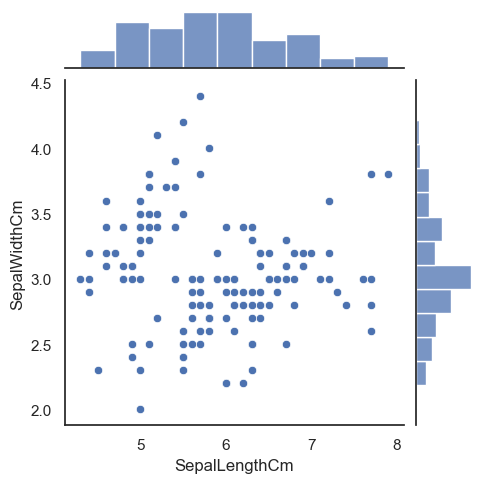

In [7]:
# Use the correct column names from the iris dataset
# Note: In newer versions of seaborn, 'size' parameter is replaced with 'height'
sns.jointplot(x="SepalLengthCm", y="SepalWidthCm", data=df_flower, height=5)
plt.savefig("results/figures/JointGrid.png", dpi=300, bbox_inches="tight")

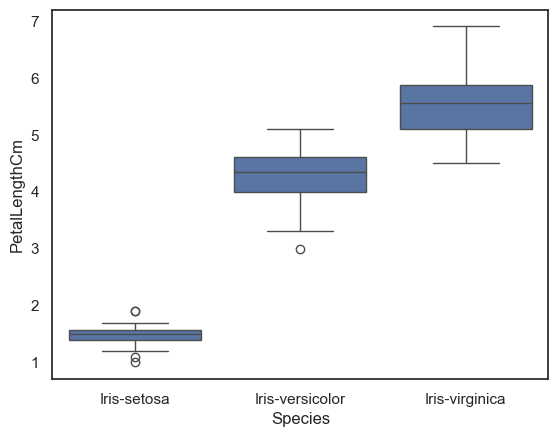

In [8]:
# looking at individual feature in seaborn
# Then use the correct column name in the boxplot
sns.boxplot(x="Species", y="PetalLengthCm", data=df_flower)
plt.savefig("results/figures/visualising individual feature in seaborn using boxplot.png", dpi=300, bbox_inches="tight")

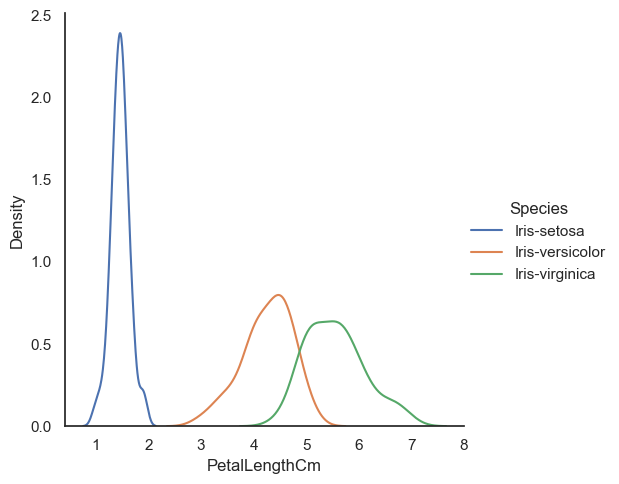

In [9]:
# Create the plot with the correct column name
sns.FacetGrid(df_flower,hue="Species", height=5) \
   .map(sns.kdeplot, "PetalLengthCm") \
   .add_legend()
plt.savefig("results/figures/visualising petal_Length using seaborn.png", dpi=300, bbox_inches="tight")

In this section we visualise relationships between sepal and petal measurements to understand feature separability between species.

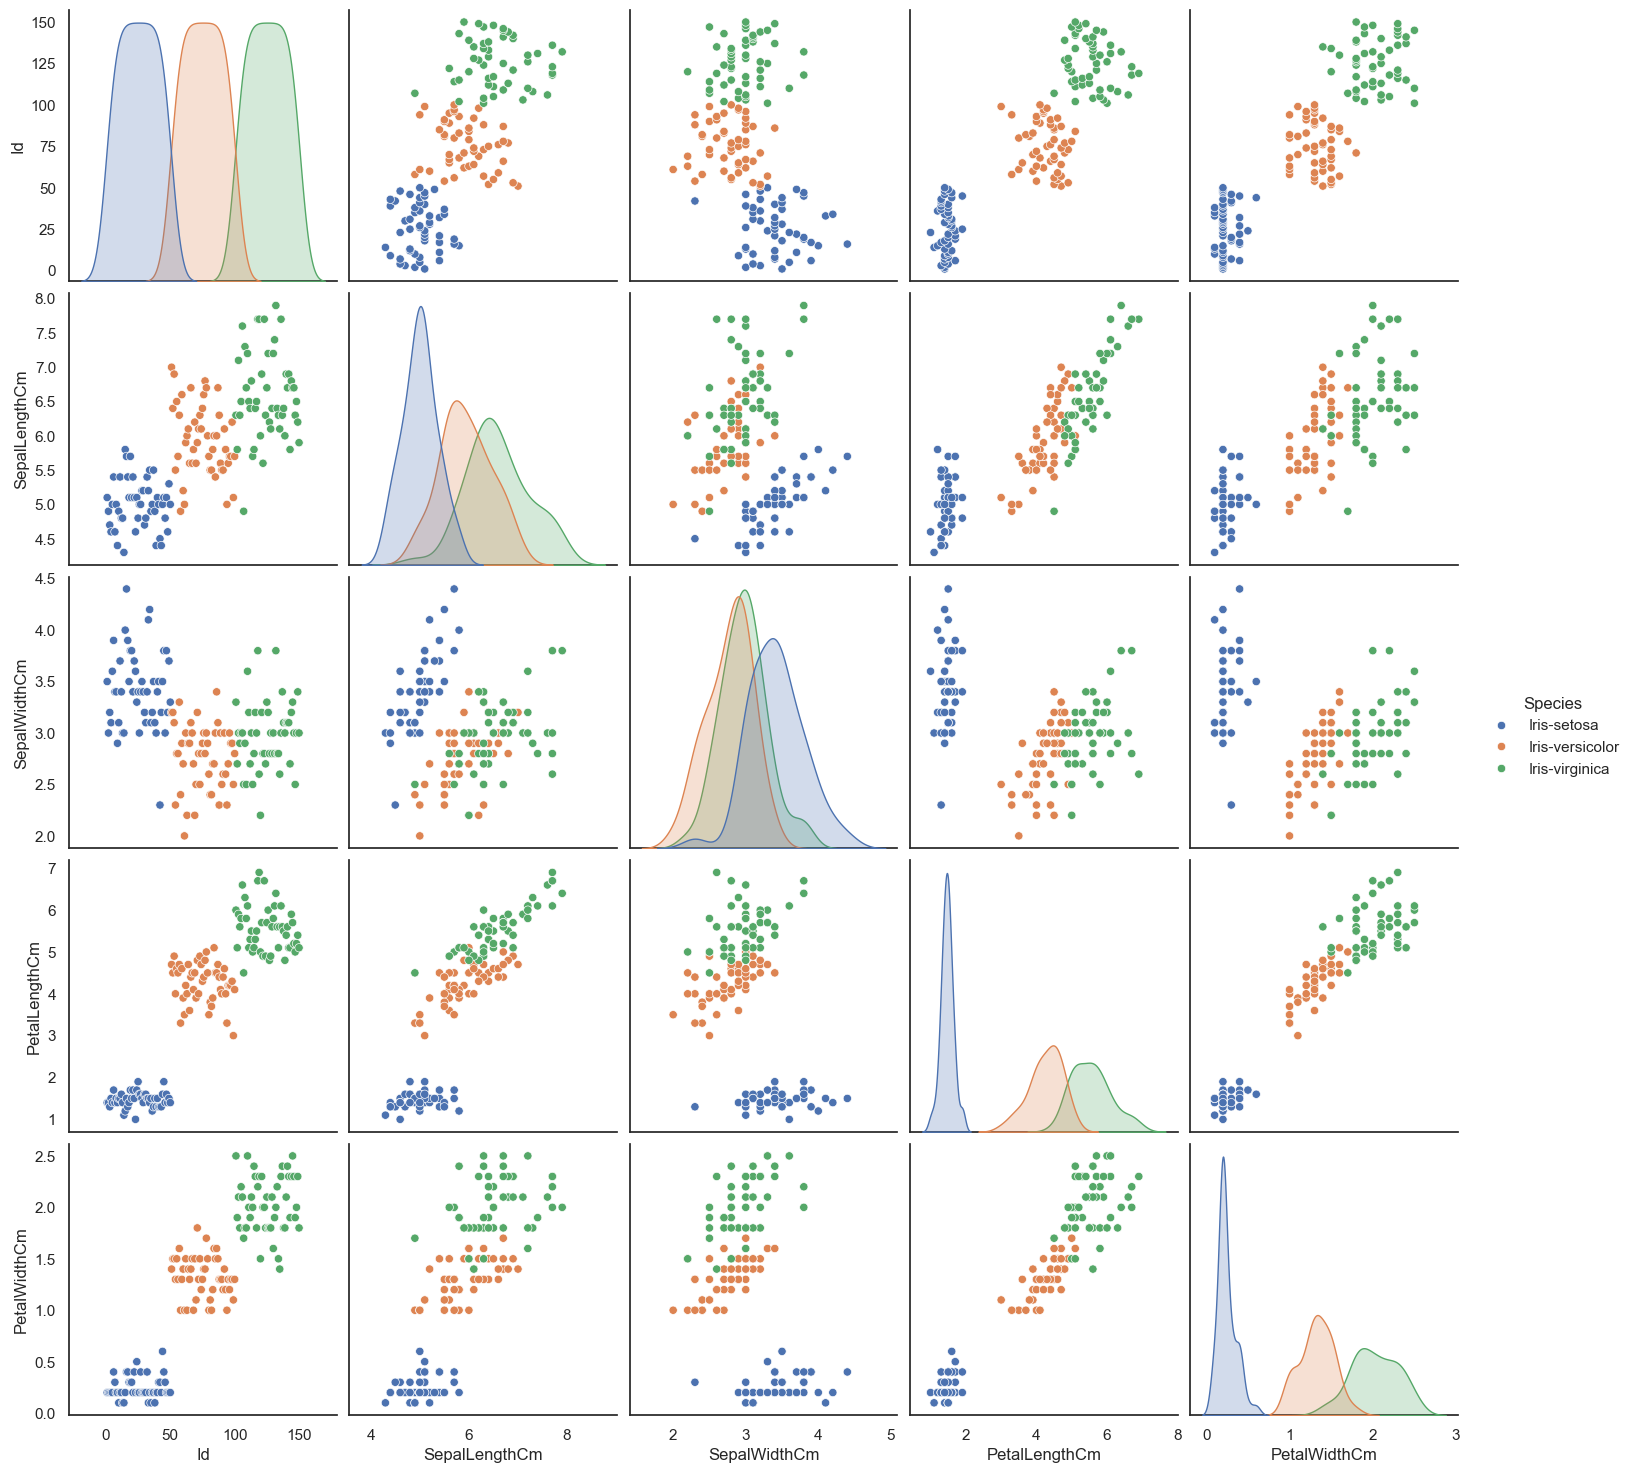

In [10]:
# Create pairplot with different colors for each species
# The 'hue' parameter colors points by species category
sns.pairplot(df_flower, hue="Species",height=3)
# Save the visualization as a high-resolution PNG file
# dpi=300 sets high resolution, bbox_inches="tight" removes extra whitespace
plt.savefig("results/figures/visualising relationships using seaborn.png", dpi=300, bbox_inches="tight")
# Display the plot in the notebook
plt.show()

Visualizing relationships between features using seaborn's pairplot.
This creates a grid of scatterplots showing pairwise relationships between variables.
Setosa appears clearly separated from other species based on petal measurements.
Versicolor and Virginica overlap slightly. This visual insight tell us classification will be feasible but not perfect.

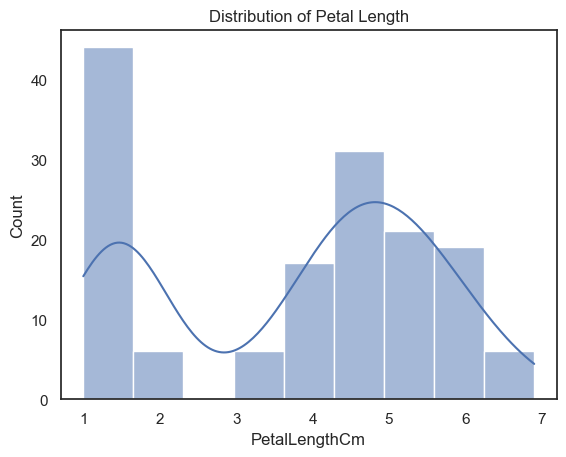

In [11]:
# Create a histogram with kernel density estimate to visualize the distribution of petal lengths
sns.histplot(df_flower["PetalLengthCm"], kde=True)
# Add a title to the plot
plt.title("Distribution of Petal Length")
# Save the figure to the specified path with high resolution (300 dpi) and tight layout
plt.savefig("results/figures/distribution of petal length.png", dpi=300, bbox_inches="tight")
# Display the plot
plt.show()

In [12]:
# Separate features (X) and target variable (y)
# Features: all columns except 'species'
X = df_flower.drop("Species", axis=1)
# Target: the 'species' column
y = df_flower["Species"]              
# random_state=42 ensures reproducibility of the split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Preparing data for modelling.
Splitting into training and testing sets.
Training data builds the model ,while testing data evaluates performance.
Split data into training (80%) and testing (20%) sets preventing overfitting

Training multiple classifiers.
The model learns the relationship between flower measurements and species

LogisticRegression

In [13]:
# Initialize the logistic regression model with increased max iterations
# This helps ensure convergence for complex datasets
log_model = LogisticRegression(max_iter=200,random_state=42)
# Train the model using the training data
# X_train contains the features, y_train contains the target labels
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,200
,multi_class,'deprecated'


In [14]:
RandomForestClassifier

sklearn.ensemble._forest.RandomForestClassifier

In [15]:
# Initialize a RandomForest classifier 
rf_model = RandomForestClassifier(random_state=42)
# Train the model using the training data
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


DecisionTreeClassifier

In [16]:
# Initialize a DecisionTreeClassifier 
dt_model = DecisionTreeClassifier(random_state=42)
# Train the model using the training data
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [17]:
# Making predictions using the trained model on the test data
# This will generate predicted values that we can compare with actual values
y_pred=log_model.predict(X_test)
# print accuracy by comparing predicted values (y_pred) with actual test values (y_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
# Print a confusion matrix by comparing the actual test labels (y_test) with predicted labels (y_pred)
# The confusion matrix shows true positives, false positives, true negatives, and false negatives
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


The logistic regression classifier achieved perfect predictive performance on the test set.
The confusion matrix showed correct classification for all 30 test observations(Setosa=10,Versicolor=9,Virginica=11).
This results reflects the strong separability of iris species using petal and sepal measurements.

Here the model attempts to classify unseen flowers

In [18]:
# Print a detailed classification report showing precision, recall, f1-score, and support
# for each species separately. This helps evaluate model performance across all classes.
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [19]:
models={"Logistic Regression":log_model,"Decision Tree":dt_model,
      "Random Forest":rf_model}
results=[]
for name,model in models.items():
    scores=cross_val_score(model,X,y,cv=5)
    results.append([name,scores.mean(),scores.std()])
df_results=pd.DataFrame(results)
print(df_results)

                     0         1         2
0  Logistic Regression  0.913333  0.106667
1        Decision Tree  0.933333  0.081650
2        Random Forest  0.946667  0.065320


Cross validation provides a more reliable performance estimate

The classification models performed strongly on the Iris dataset.
Random Forest achieved the highest cross validation accuracy (~95%) because it reduces variance through ensembling learning,followed by Decision Tree and Logistic Regression.